# MACRO GROUP 3 – Monetary Policy and the Fisher Effect

## Authors
Lorenzo Ilari,
Matteo Pugliese,
Nicholas Friend,
Alexandra Ciornei,
Amalie Hulaas.

## Research Question

This notebook investigates whether the Fisher equation holds in the United States using macroeconomic data.

The Fisher equation states that the nominal interest rate should reflect the real interest rate plus expected inflation:

$$
i_t = r_t + \pi_t
$$

Empirically, we test whether nominal interest rates move approximately one-for-one with inflation:

$$
i_t = \alpha + \beta \pi_t + \varepsilon_t
$$

If the Fisher effect holds strongly, the estimated coefficient $\beta$ should be close to 1.

We also analyse how nominal interest rates relate to money supply growth and simulate future interest rate scenarios under alternative inflation regimes.

# 0. SETUP


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats

# Reproducibility
np.random.seed(42)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# 1. DATA LOADING AND FIRST LOOK

In this section, we load the `macrodata` dataset from `statsmodels`.

The key variables used in this analysis are:

- `tbilrate`: nominal interest rate
- `infl`: inflation rate
- `realint`: real interest rate
- `m1`: money supply

We first inspect the dataset structure, the data types, the first observations, and the main descriptive statistics.

 ##  1.1 Dataset



In [2]:
macro = sm.datasets.macrodata.load_pandas().data

print("Dataset loaded successfully.")
print(f"Shape of the dataset: {macro.shape}")

Dataset loaded successfully.
Shape of the dataset: (203, 14)


### Data types

In [3]:
macro.dtypes

year        float64
quarter     float64
realgdp     float64
realcons    float64
realinv     float64
realgovt    float64
realdpi     float64
cpi         float64
m1          float64
tbilrate    float64
unemp       float64
pop         float64
infl        float64
realint     float64
dtype: object

### First look at data

In [4]:
macro.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.000,1.000,2710.349,1707.400,286.898,470.045,1886.900,28.980,139.700,2.820,5.800,177.146,0.000,0.000
1,1959.000,2.000,2778.801,1733.700,310.859,481.301,1919.700,29.150,141.700,3.080,5.100,177.830,2.340,0.740
2,1959.000,3.000,2775.488,1751.800,289.226,491.260,1916.400,29.350,140.500,3.820,5.300,178.657,2.740,1.090
3,1959.000,4.000,2785.204,1753.700,299.356,484.052,1931.300,29.370,140.000,4.330,5.600,179.386,0.270,4.060
4,1960.000,1.000,2847.699,1770.500,331.722,462.199,1955.500,29.540,139.600,3.500,5.200,180.007,2.310,1.190


### Summary


In [5]:
macro.describe()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
count,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000,203.000
mean,1983.877,2.493,7221.172,4825.293,1012.864,663.329,5310.541,105.076,667.928,5.312,5.885,239.724,3.961,1.337
std,14.687,1.119,3214.956,2313.346,585.102,140.864,2423.516,61.279,455.346,2.803,1.459,37.390,3.253,2.669
min,1959.000,1.000,2710.349,1707.400,259.764,460.400,1886.900,28.980,139.600,0.120,3.400,177.146,-8.790,-6.790
25%,1971.000,1.500,4440.104,2874.100,519.148,527.959,3276.950,41.050,228.650,3.515,4.900,208.631,2.270,-0.085
50%,1984.000,2.000,6559.594,4299.900,896.210,662.412,4959.400,104.100,540.900,5.010,5.700,236.348,3.240,1.340
75%,1996.500,3.000,9629.346,6398.150,1436.682,773.049,6977.850,159.650,1102.100,6.665,6.800,271.721,4.975,2.630
max,2009.000,4.000,13415.266,9363.600,2264.721,1044.088,10077.500,218.610,1673.900,15.330,10.700,308.013,14.620,10.950


## 1.2 Assign a Quarterly DateTimeIndex

The dataset contains quarterly macroeconomic observations.  
To make the time-series analysis easier, we assign a quarterly date index starting in 1959 Q1.

In [6]:
# Create a quarterly date range starting from 1959 Q1
quarterly_index = pd.period_range(start="1959Q1", periods=len(macro), freq="Q")

# Assign the index to the DataFrame
macro.index = quarterly_index

# Check the result
macro.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959Q1,1959.000,1.000,2710.349,1707.400,286.898,470.045,1886.900,28.980,139.700,2.820,5.800,177.146,0.000,0.000
1959Q2,1959.000,2.000,2778.801,1733.700,310.859,481.301,1919.700,29.150,141.700,3.080,5.100,177.830,2.340,0.740
1959Q3,1959.000,3.000,2775.488,1751.800,289.226,491.260,1916.400,29.350,140.500,3.820,5.300,178.657,2.740,1.090
1959Q4,1959.000,4.000,2785.204,1753.700,299.356,484.052,1931.300,29.370,140.000,4.330,5.600,179.386,0.270,4.060
1960Q1,1960.000,1.000,2847.699,1770.500,331.722,462.199,1955.500,29.540,139.600,3.500,5.200,180.007,2.310,1.190


In [7]:
print(f"Start date: {macro.index.min()}")
print(f"End date: {macro.index.max()}")
print(f"Number of observations: {len(macro)}")

Start date: 1959Q1
End date: 2009Q3
Number of observations: 203


## 1.3 Missing Values

Before transforming the data, we check whether the original dataset contains missing values.  
This is important because missing values can affect regressions, correlations, and plots.

In [8]:
# More readable missing values table
missing_table = pd.DataFrame({
    "Missing values": macro.isna().sum(),
    "Missing percentage": macro.isna().mean() * 100
})

missing_table

,Missing values,Missing percentage
year,0,0.000
quarter,0,0.000
realgdp,0,0.000
realcons,0,0.000
realinv,0,0.000
realgovt,0,0.000
realdpi,0,0.000
cpi,0,0.000
m1,0,0.000
tbilrate,0,0.000


# 2. DATA PREPATARION

In this section, we create the variables required for the empirical analysis.

The new variables are:

- `m1_growth`: annualised quarterly money supply growth rate, calculated as $400 \times \Delta \ln(m1_t)$
- `infl_lag1`: inflation lagged by one quarter, used as a simple proxy for expected inflation
- `fisher_residual`: difference between the nominal interest rate and inflation
- `decade`: decade of each observation, used for grouped summary statistics

Rows with missing values introduced by transformations are removed.

## 2.1 CREATE NEW VARIABLES


In [9]:
macro_prepared = macro.copy()

# Annualised quarterly money supply growth rate
macro_prepared["m1_growth"] = 400 * np.log(macro_prepared["m1"]).diff()

# Inflation lagged by one quarter
macro_prepared["infl_lag1"] = macro_prepared["infl"].shift(1)

# Fisher residual: nominal interest rate minus inflation
macro_prepared["fisher_residual"] = macro_prepared["tbilrate"] - macro_prepared["infl"]

# Display the first rows to inspect the new variables
macro_prepared[["tbilrate", "infl", "realint", "m1", "m1_growth", "infl_lag1", "fisher_residual"]].head(10)

,tbilrate,infl,realint,m1,m1_growth,infl_lag1,fisher_residual
1959Q1,2.820,0.000,0.000,139.700,NaN,NaN,2.820
1959Q2,3.080,2.340,0.740,141.700,5.686,0.000,0.740
1959Q3,3.820,2.740,1.090,140.500,-3.402,2.340,1.080
1959Q4,4.330,0.270,4.060,140.000,-1.426,2.740,4.060
1960Q1,3.500,2.310,1.190,139.600,-1.144,0.270,1.190
1960Q2,2.680,0.140,2.550,140.200,1.716,2.310,2.540
1960Q3,2.360,2.700,-0.340,140.900,1.992,0.140,-0.340
1960Q4,2.290,1.210,1.080,141.100,0.567,2.700,1.080
1961Q1,2.370,-0.400,2.770,142.100,2.825,1.210,2.770
1961Q2,2.290,1.470,0.810,142.900,2.246,-0.400,0.820


## 2.2 Remove Missing Values

The transformations above introduce missing values:

- `m1_growth` is missing in the first observation because it uses a first difference.
- `infl_lag1` is missing in the first observation because it uses a one-period lag.

We remove these rows before running the empirical analysis.

In [10]:
print("Missing values before dropping:")
print(macro_prepared[["m1_growth", "infl_lag1", "fisher_residual"]].isna().sum())

macro_clean = macro_prepared.dropna().copy()      # pandas Dataframe

print("\nShape before dropping missing values:", macro_prepared.shape)
print("Shape after dropping missing values:", macro_clean.shape)

Missing values before dropping:
m1_growth          1
infl_lag1          1
fisher_residual    0
dtype: int64

Shape before dropping missing values: (203, 17)
Shape after dropping missing values: (202, 17)


## 2.3 Create Decade Variable

We create a `decade` column to group observations by decade.  
This allows us to compare average interest rates, inflation, real interest rates, and money supply growth across different historical periods.

In [11]:
macro_clean["year"] = macro_clean.index.year
macro_clean["decade"] = (macro_clean["year"] // 10) * 10

macro_clean["decade"] = macro_clean["decade"].astype(str) + "s"

macro_clean[["tbilrate", "infl", "realint", "m1_growth", "decade"]].head()

,tbilrate,infl,realint,m1_growth,decade
1959Q2,3.080,2.340,0.740,5.686,1950s
1959Q3,3.820,2.740,1.090,-3.402,1950s
1959Q4,4.330,0.270,4.060,-1.426,1950s
1960Q1,3.500,2.310,1.190,-1.144,1960s
1960Q2,2.680,0.140,2.550,1.716,1960s


In [12]:
# Check the number of observations by decade
macro_clean["decade"].value_counts().sort_index()

decade
1950s     3
1960s    40
1970s    40
1980s    40
1990s    40
2000s    39
Name: count, dtype: int64

# 3. EXPLANATORY DATA ANALYSIS

In this section, we explore the behaviour of nominal interest rates, inflation, real interest rates, and money supply growth over time.

The goals are to:

- compare the time-series dynamics of `tbilrate`, `infl`, and `realint`;
- identify whether real interest rates became negative;
- compare the Fisher residual with the observed real interest rate;
- summarise the key variables by decade;
- analyse correlations among nominal rates, inflation, real interest rates, and money supply growth.

## 3.1 Time-Series Plots of Interest Rates and Inflation

We plot the nominal interest rate, inflation, and the real interest rate in three stacked time-aligned subplots.

The real interest rate panel includes a zero reference line, which helps identify periods in which real interest rates were negative.

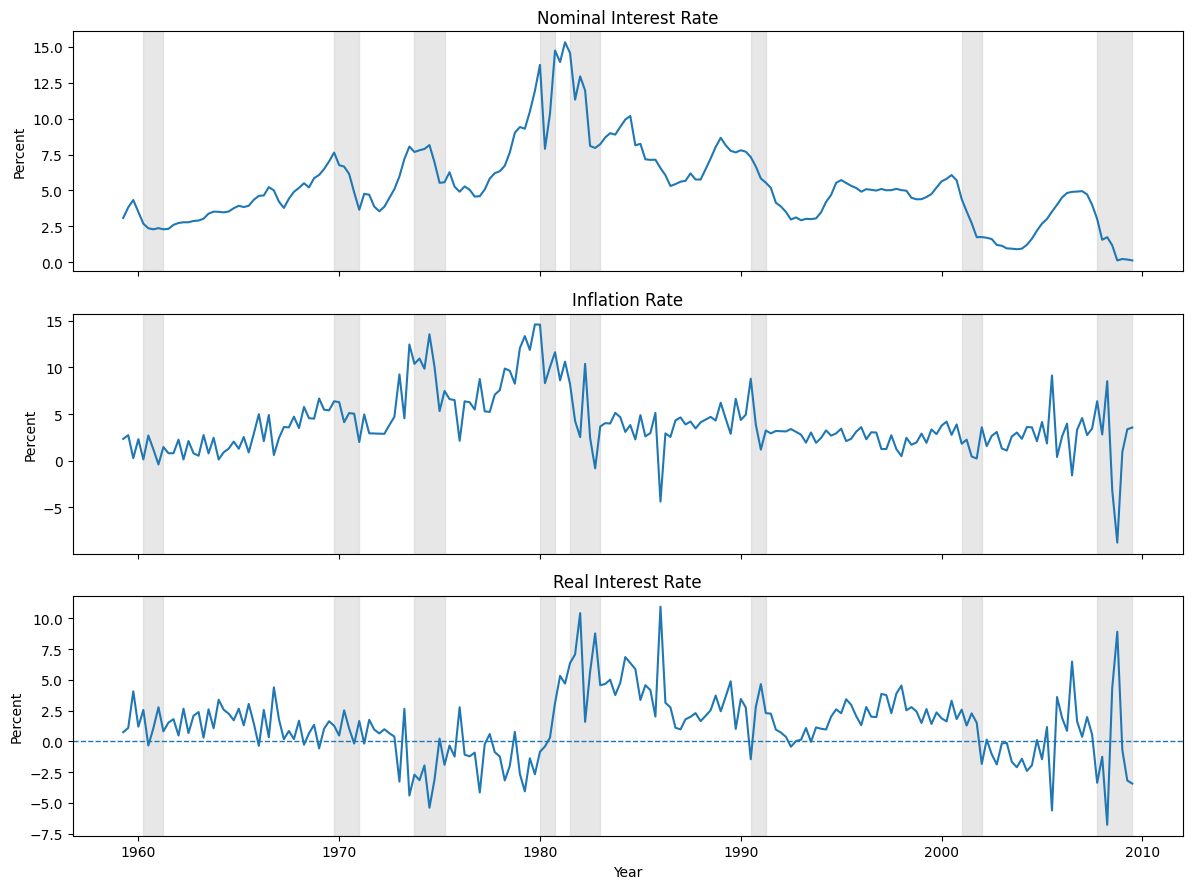

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# NBER recession periods
recession = [
    ("1960Q2", "1961Q1"), ("1969Q4", "1970Q4"), ("1973Q4", "1975Q1"),
    ("1980Q1", "1980Q3"), ("1981Q3", "1982Q4"), ("1990Q3", "1991Q1"),
    ("2001Q1", "2001Q4"), ("2007Q4", "2009Q2"),
]

def add_recession_shading(ax, recessions=recession):
    """Shade recession periods on a matplotlib Axes with a timestamp x-axis."""
    for start, end in recessions:
        start_date = pd.Period(start, freq="Q").to_timestamp()        # x-axis is made of dates/timestamps, get_loc(start) gives an integer position
        end_date = pd.Period(end, freq="Q").to_timestamp(how="end")

        ax.axvspan(
            start_date,
            end_date,
            color="#d0d0d0",
            alpha=0.5,
            zorder=0
        )

# Nominal interest rate
axes[0].plot(macro_clean.index.to_timestamp(), macro_clean["tbilrate"])
add_recession_shading(axes[0])
axes[0].set_title("Nominal Interest Rate")
axes[0].set_ylabel("Percent")

# Inflation
axes[1].plot(macro_clean.index.to_timestamp(), macro_clean["infl"])
add_recession_shading(axes[1])
axes[1].set_title("Inflation Rate")
axes[1].set_ylabel("Percent")

# Real interest rate
axes[2].plot(macro_clean.index.to_timestamp(), macro_clean["realint"])
axes[2].axhline(0, linestyle="--", linewidth=1)
add_recession_shading(axes[2])
axes[2].set_title("Real Interest Rate")
axes[2].set_ylabel("Percent")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

In [14]:
# Identify periods with negative real interest rates
negative_realint = macro_clean[macro_clean["realint"] < 0]

print(f"Number of quarters with negative real interest rates: {len(negative_realint)}")
print(f"First quarter with negative real interest rates: {negative_realint.index.min()}")
print(f"Last quarter with negative real interest rates: {negative_realint.index.max()}")

negative_realint[["tbilrate", "infl", "realint"]].head(10)

Number of quarters with negative real interest rates: 52
First quarter with negative real interest rates: 1960Q3
Last quarter with negative real interest rates: 2009Q3


,tbilrate,infl,realint
1960Q3,2.360,2.700,-0.340
1966Q1,4.620,4.990,-0.370
1968Q2,5.500,5.770,-0.280
1969Q1,6.080,6.670,-0.580
1970Q4,4.860,5.040,-0.180
1971Q2,4.760,4.960,-0.190
1973Q1,5.980,9.260,-3.280
1973Q3,8.060,12.470,-4.410
1973Q4,7.680,10.390,-2.710
1974Q1,7.800,10.960,-3.160


## 3.2 Fisher Residual and Real Interest Rate

The Fisher decomposition implies:

$$
i_t = r_t + \pi_t
$$

Rearranging the equation gives:

$$
r_t = i_t - \pi_t
$$

Therefore, the variable `fisher_residual`, defined as `tbilrate - infl`, should be closely related to the observed `realint` variable.

We use a scatter plot to compare the two series. A 45-degree line is added as a reference. If the two variables were identical, all points would lie on this line.

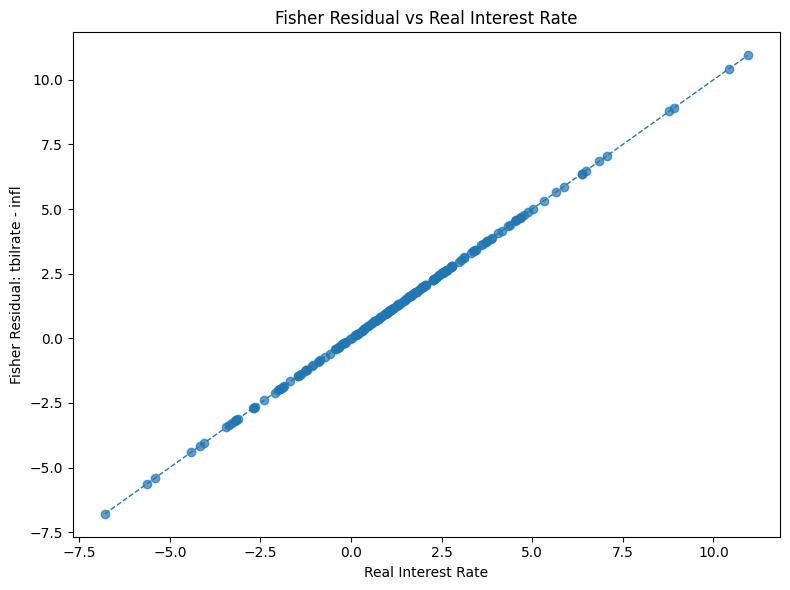

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    macro_clean["realint"],
    macro_clean["fisher_residual"],
    alpha=0.7
)

# 45-degree reference line
min_val = min(macro_clean["realint"].min(), macro_clean["fisher_residual"].min())
max_val = max(macro_clean["realint"].max(), macro_clean["fisher_residual"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

plt.title("Fisher Residual vs Real Interest Rate")
plt.xlabel("Real Interest Rate")
plt.ylabel("Fisher Residual: tbilrate - infl")

plt.tight_layout()
plt.show()

In [16]:
# Correlation and average difference between the two series

fisher_realint_corr = macro_clean["fisher_residual"].corr(macro_clean["realint"])
mean_difference = (macro_clean["fisher_residual"] - macro_clean["realint"]).mean()

print(f"Correlation between fisher_residual and realint: {fisher_realint_corr:.3f}")
print(f"Average difference between fisher_residual and realint: {mean_difference:.3f}")

Correlation between fisher_residual and realint: 1.000
Average difference between fisher_residual and realint: 0.000


## 3.3 Decade-Level Summary Statistics

We compute the average values of nominal interest rates, inflation, real interest rates, and money supply growth by decade.

This allows us to compare different macroeconomic periods and identify which decades had the highest average inflation and real interest rates.

In [17]:
decade_summary = (
    macro_clean
    .groupby("decade")[["tbilrate", "infl", "realint", "m1_growth"]]
    .mean()
    .round(2)
)

decade_summary

,tbilrate,infl,realint,m1_growth
decade,,,,
1950s,3.740,1.780,1.960,0.290
1960s,4.010,2.550,1.460,3.870
1970s,6.330,7.220,-0.890,6.260
1980s,8.790,4.910,3.870,7.240
1990s,4.830,2.830,2.000,3.440
2000s,2.720,2.520,0.200,4.100


In [18]:
# Identify decades with highest inflation and highest real interest rates

highest_inflation_decade = decade_summary["infl"].idxmax()
highest_realint_decade = decade_summary["realint"].idxmax()

print(f"Decade with the highest average inflation: {highest_inflation_decade}")
print(f"Decade with the highest average real interest rate: {highest_realint_decade}")

Decade with the highest average inflation: 1970s
Decade with the highest average real interest rate: 1980s


## 3.4 Correlation Matrix

Finally, we compute the Pearson correlation matrix for:

- `tbilrate`
- `infl`
- `realint`
- `m1_growth`

This helps us evaluate the linear association between nominal interest rates, inflation, real interest rates, and money supply growth.

In [19]:
corr_vars = ["tbilrate", "infl", "realint", "m1_growth"]

corr_matrix = macro_clean[corr_vars].corr()

corr_matrix.round(3)

,tbilrate,infl,realint,m1_growth
tbilrate,1.000,0.619,0.297,-0.006
infl,0.619,1.000,-0.566,-0.051
realint,0.297,-0.566,1.000,0.055
m1_growth,-0.006,-0.051,0.055,1.000


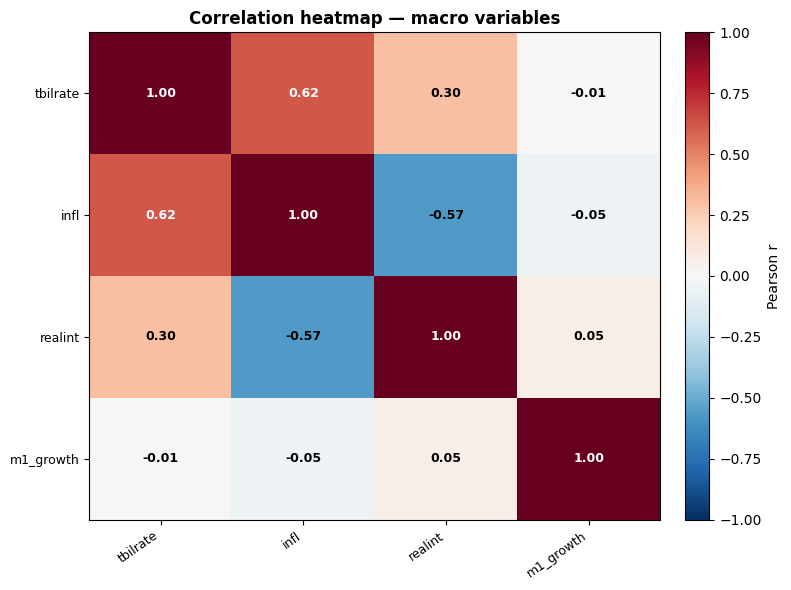

In [20]:
import matplotlib.pyplot as plt

# Create a new figure and axes for the heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Simple visualisation of the correlation matrix
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
n = len(corr_vars)

# Define labels for the correlation matrix
labels = corr_vars

for i in range(n):
    for j in range(n):
        # Use white text on dark cells so the numbers stay legible
        color = 'white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black'
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title('Correlation heatmap — macro variables', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. ECONOMETRIC ANALYSIS

In this section, we estimate the Fisher equation.

The basic Fisher equation can be written as:

$$
i_t = \alpha + \beta \pi_t + \varepsilon_t
$$

where:

- $i_t$ is the nominal interest rate
- $\pi_t$ is the inflation rate
- $\alpha$ is the intercept
- $\beta$ measures the response of nominal interest rates to inflation

According to the Fisher effect, nominal interest rates should increase approximately one-for-one with inflation. Therefore, if the Fisher effect holds strongly, the coefficient $\beta$ should be close to 1.

## 4.1 Fisher Equation Estimated with NumPy

We first estimate the basic Fisher equation using NumPy.

- The dependent variable is `tbilrate`, the nominal interest rate.  
- The independent variable is `infl`, the inflation rate.

In [21]:
# Define the OLS function
def ols_estimate(y, X, add_constant=True):
    """
    OLS estimation with homoscedastic standard errors.

    Parameters
    ----------
    y : array_like, shape (T,)
        Dependent variable.
    X : array_like, shape (T, k) or (T,)
        Regressors. Do NOT include a column of ones unless add_constant=False.
    add_constant : bool
        If True, prepend a column of ones (intercept).

    Returns
    -------
    dict with keys beta, se, t_stat, resid, sigma2, r_squared.
    """
    # 1. Normalise shapes
    y = np.asarray(y).flatten()
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # 2. Add the intercept column if requested
    if add_constant:
        X = np.column_stack([np.ones(X.shape[0]), X])

    T, k = X.shape

    # 3. β̂ = (X'X)⁻¹ X'y
    XtX_inv = np.linalg.inv(X.T @ X)
    beta    = XtX_inv @ (X.T @ y)

    # 4. Residuals and σ̂²
    resid  = y - X @ beta
    sigma2 = (resid @ resid) / (T - k)

    # 5. Standard errors and t-statistics
    se     = np.sqrt(np.diag(sigma2 * XtX_inv))
    t_stat = beta / se

    # 6. R²
    ss_tot    = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - (resid @ resid) / ss_tot

    return {'beta': beta, 'se': se, 't_stat': t_stat,
            'resid': resid, 'sigma2': sigma2, 'r_squared': r_squared}

In [22]:
# Define dependent and independent variables
y = macro_clean["tbilrate"].values
x = macro_clean["infl"].values

# Run OLS
m = ols_estimate(y, x, add_constant=True)
resid_se = np.sqrt(m["sigma2"])

In [23]:
print('Fisher Equation OLS')
print(f'α  (intercept) : {m["beta"][0]:+.4f}  (SE {m["se"][0]:.4f},  t {m["t_stat"][0]:+.2f})')
print(f'ß  (Beta)      : {m["beta"][1]:+.4f}  (SE {m["se"][1]:.4f},  t {m["t_stat"][1]:+.2f})')
print(f'R²             : {m["r_squared"]:.4f}')
print(f'Residual SE    : {resid_se:.4f}')

Fisher Equation OLS
α  (intercept) : +3.1985  (SE 0.2462,  t +12.99)
ß  (Beta)      : +0.5339  (SE 0.0480,  t +11.13)
R²             : 0.3827
Residual SE    : 2.2090


## 4.2 Extended Fisher Model with Money Supply Growth

We now estimate an extended Fisher equation by adding money supply growth as an additional regressor.

The model is:

$$
i_t = \alpha + \beta_1 \pi_t + \beta_2 \Delta m1_t + \varepsilon_t
$$

where:

- $i_t$ is the nominal interest rate, measured by `tbilrate`
- $\pi_t$ is inflation, measured by `infl`
- $\Delta m1_t$ is money supply growth, measured by `m1_growth`

The goal is to check whether adding money supply growth improves the explanatory power of the model, whether the coefficient on money supply growth is positive or negative, and whether the inflation coefficient remains close to 1.




In [24]:
# Dependent variable
y = macro_clean["tbilrate"]

# Independent variables: inflation and money supply growth
X_extended = macro_clean[["infl", "m1_growth"]]

# Add intercept
X_extended = sm.add_constant(X_extended)

# Estimate OLS model
extended_model = sm.OLS(y, X_extended).fit()

# Print full regression summary
print(extended_model.summary())

                            OLS Regression Results                            
Dep. Variable:               tbilrate   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     61.85
Date:                Sun, 24 May 2026   Prob (F-statistic):           1.29e-21
Time:                        22:43:47   Log-Likelihood:                -445.61
No. Observations:                 202   AIC:                             897.2
Df Residuals:                     199   BIC:                             907.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1265      0.293     10.669      0.0

Adding money supply growth does not meaningfully improve the model, since $R^2$
 remains about 0.383. The coefficient on money supply growth is positive, but very small and statistically insignificant. The inflation coefficient remains positive and significant, but at about 0.535 it is not close to 1, so the data do not strongly support a one-for-one Fisher effect.

# 5. SIMULATION

In this section, we use the estimated parameters from Task 4.2 to simulate nominal interest rates for the next 16 quarters.

The model is:

$$
i_t = \alpha + \beta_1 \pi_t + \beta_2 \Delta m1_t + \varepsilon_t
$$

where:

- $i_t$ is the nominal interest rate
- $\pi_t$ is inflation
- $\Delta m1_t$ is money supply growth
- $\varepsilon_t$ is a normally distributed shock

We consider two scenarios:

1. **High-inflation scenario**: $\pi = 6\%$, $\Delta m1$ $= 8\%$
2. **Low-inflation scenario**: $\pi = 1.5\%$, $\Delta m1$ $= 3\%$

For each scenario, we run 300 simulations over the next 16 quarters. In each quarter, we add normally distributed noise:

$$
\varepsilon \sim N(0, \hat{\sigma}^2)
$$

where $\hat{\sigma}^2$ is the residual variance estimated in Task 4.2.

## 5.1 Define the Two Scenarios

For each scenario, the deterministic model prediction is:


$$
\hat{i}_t = \hat{\alpha} + \hat{\beta}_1 \pi_t + \hat{\beta}_2 \mu_t
$$


We then add random shocks to generate simulated interest rate paths.

In [25]:
# Number of future quarters and simulations
n_quarters = 16
n_simulations = 300

# Last observed nominal interest rate
last_tbilrate = macro_clean["tbilrate"].iloc[-1]

# Future quarterly index, starting from the last observed quarter
plot_index = pd.period_range(
    start=macro_clean.index[-1],
    periods=n_quarters + 1,
    freq="Q"
)

# Estimated parameters from Task 4.2
alpha_hat = extended_model.params["const"]
beta_infl_hat = extended_model.params["infl"]
beta_m1_hat = extended_model.params["m1_growth"]

# Estimated residual standard deviation
sigma_hat = np.sqrt(extended_model.mse_resid)

print(f"Estimated alpha: {alpha_hat:.3f}")
print(f"Estimated beta for inflation: {beta_infl_hat:.3f}")
print(f"Estimated beta for money supply growth: {beta_m1_hat:.3f}")
print(f"Estimated residual standard deviation: {sigma_hat:.3f}")

Estimated alpha: 3.126
Estimated beta for inflation: 0.535
Estimated beta for money supply growth: 0.014
Estimated residual standard deviation: 2.213


In [26]:
# Scenarios
scenarios = {
    "High inflation": {
        "infl": 6.0,
        "m1_growth": 8.0
    },
    "Low inflation": {
        "infl": 1.5,
        "m1_growth": 3.0
    }
}

In [ ]:
# Run the simulation
simulation_results = {}

for scenario_name, values in scenarios.items():

    infl = values["infl"]
    m1_growth = values["m1_growth"]

    # Model prediction for the scenario
    model_prediction = (
        alpha_hat
        + beta_infl_hat * infl
        + beta_m1_hat * m1_growth
    )

    # Random shocks: epsilon ~ N(0, sigma_hat^2)
    shocks = np.random.normal(
        loc=0,
        scale=sigma_hat,
        size=(n_simulations, n_quarters)
    )

    # Simulated future paths
    future_paths = model_prediction + shocks

    # Add the last observed tbilrate as the starting value
    paths_with_start = np.column_stack([
        np.full(n_simulations, last_tbilrate),
        future_paths
    ])

    simulation_results[scenario_name] = paths_with_start

In [ ]:
# Compute median, 10th and 90th percentile
summary_results = {}

for scenario_name, paths in simulation_results.items():

    summary_results[scenario_name] = pd.DataFrame({
        "median": np.percentile(paths, 50, axis=0),
        "p10": np.percentile(paths, 10, axis=0),
        "p90": np.percentile(paths, 90, axis=0)
    }, index=plot_index)

summary_results["High inflation"].round(3)

,median,p10,p90
2009Q3,0.120,0.120,0.120
2009Q4,6.437,3.889,9.292
2010Q1,6.395,3.516,9.398
2010Q2,6.323,3.673,9.060
2010Q3,6.450,3.601,9.091
2010Q4,6.734,3.974,9.206
2011Q1,6.444,3.603,9.284
2011Q2,6.394,3.503,9.150
2011Q3,6.348,4.061,9.349
2011Q4,6.487,3.370,9.191


## 5.2 Plot the Simulation Results

We plot both scenarios on the same chart, starting from the last observed value of `tbilrate`.

The solid lines show the median simulated path.  
The shaded areas show the 10th–90th percentile band for each scenario.

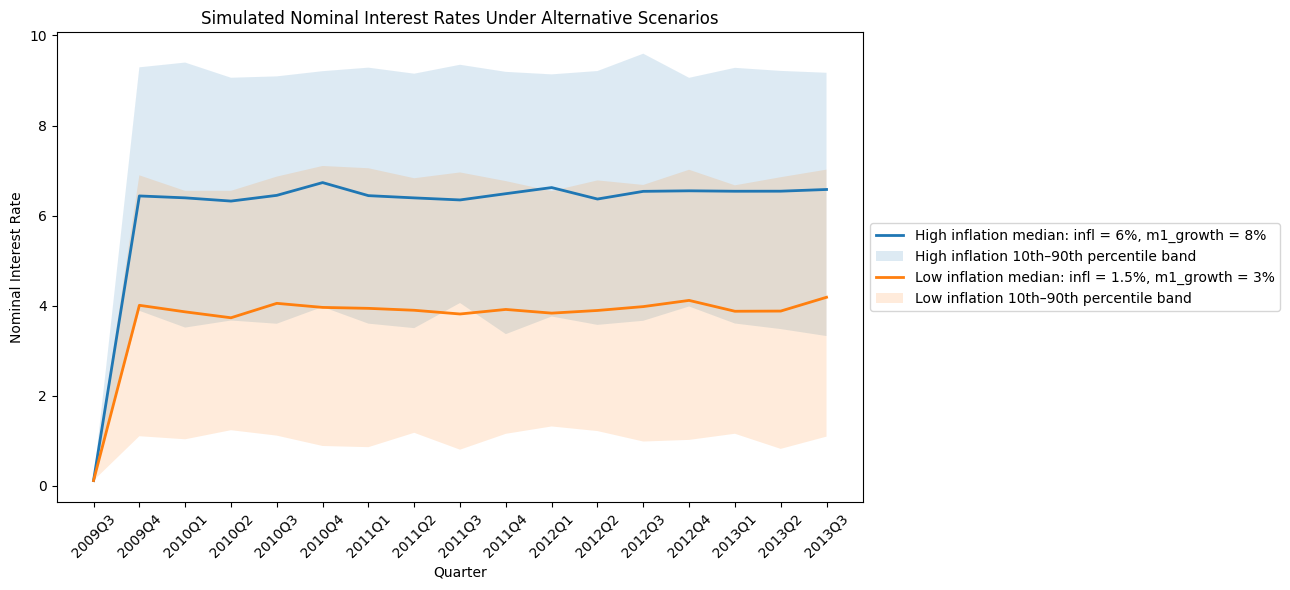

In [ ]:
# Plot both scenarios
plt.figure(figsize=(13, 6))
quarters = summary_results["High inflation"].index.astype(str)

x = range(len(quarters))

# High-inflation scenario
high = summary_results["High inflation"]

plt.plot(
    x,
    high["median"],
    linewidth=2,
    label="High inflation median: infl = 6%, m1_growth = 8%"
)

plt.fill_between(
    x,
    high["p10"],
    high["p90"],
    alpha=0.15,
    label="High inflation 10th–90th percentile band"
)

# Low-inflation scenario
low = summary_results["Low inflation"]

plt.plot(
    x,
    low["median"],
    linewidth=2,
    label="Low inflation median: infl = 1.5%, m1_growth = 3%"
)

plt.fill_between(
    x,
    low["p10"],
    low["p90"],
    alpha=0.15,
    label="Low inflation 10th–90th percentile band"
)

plt.title("Simulated Nominal Interest Rates Under Alternative Scenarios")
plt.xlabel("Quarter")
plt.ylabel("Nominal Interest Rate")

# Use quarter labels from the simulation result index
plt.xticks(
    ticks=x,
    labels=quarters,
    rotation=45
)

# Legend outside the plot
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

The simulation shows how the nominal interest rate may evolve under two alternative macroeconomic scenarios.

The high-inflation scenario produces a higher median interest rate path because both inflation and money supply growth are assumed to be higher.

The low-inflation scenario produces a lower median path because inflation and money supply growth are assumed to be lower.

The shaded areas show uncertainty around each scenario. They represent the 10th–90th percentile range across the 300 simulated paths.


# 6. WRAP-UP

The exploratory analysis shows a positive relationship between nominal interest rates and inflation, while the relationship between nominal rates and money supply growth appears weaker and less direct. Real interest rates were negative in some periods, suggesting that nominal rates did not always fully compensate for inflation in the short run.

The Fisher effect holds only partially in this dataset: inflation is positively related to nominal interest rates, but the estimated coefficient is not necessarily exactly equal to 1, so the one-for-one relationship is not perfect quantitatively.

Adding money supply growth to the regression helps evaluate whether monetary expansion improves the explanation of nominal interest rates, but the key Fisher mechanism remains the response of nominal rates to inflation.

The simulations suggest that nominal interest rates are higher under the high-inflation scenario, where inflation is 6% and `m1_growth` is 8%, than under the low-inflation scenario, where inflation is 1.5% and `m1_growth` is 3%.

Overall, the results support the basic intuition of the Fisher effect, but they also show that the relationship is imperfect and affected by broader monetary conditions.